In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df1=pd.read_csv("spotify_data clean.csv")

In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

In [4]:
df2=pd.read_csv("track_data_final.csv")

In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8778 entries, 0 to 8777
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8778 non-null   object 
 1   track_name          8776 non-null   object 
 2   track_number        8778 non-null   int64  
 3   track_popularity    8778 non-null   int64  
 4   track_duration_ms   8778 non-null   int64  
 5   explicit            8778 non-null   bool   
 6   artist_name         8774 non-null   object 
 7   artist_popularity   8774 non-null   float64
 8   artist_followers    8774 non-null   float64
 9   artist_genres       8774 non-null   object 
 10  album_id            8778 non-null   object 
 11  album_name          8776 non-null   object 
 12  album_release_date  8778 non-null   object 
 13  album_total_tracks  8778 non-null   int64  
 14  album_type          8778 non-null   object 
dtypes: bool(1), float64(2), int64(4), object(8)
memory usag

In [6]:
df2_subset = df2[['track_id', 'track_duration_ms']].copy()

In [7]:
merged_df = pd.merge(df1, df2_subset, on='track_id', how='left')

In [8]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
 15  track_duration_ms   8582 non-null   int64  
dtypes: boo

In [9]:
# Convert to datetime for time-based analysis and feature engineering
merged_df['album_release_date'] = pd.to_datetime(merged_df['album_release_date'], errors='coerce')

In [10]:
merged_df['explicit'] = merged_df['explicit'].astype(int)

In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8582 non-null   object        
 1   track_name          8582 non-null   object        
 2   track_number        8582 non-null   int64         
 3   track_popularity    8582 non-null   int64         
 4   explicit            8582 non-null   int32         
 5   artist_name         8579 non-null   object        
 6   artist_popularity   8582 non-null   int64         
 7   artist_followers    8582 non-null   int64         
 8   artist_genres       5221 non-null   object        
 9   album_id            8582 non-null   object        
 10  album_name          8582 non-null   object        
 11  album_release_date  8582 non-null   datetime64[ns]
 12  album_total_tracks  8582 non-null   int64         
 13  album_type          8582 non-null   object      

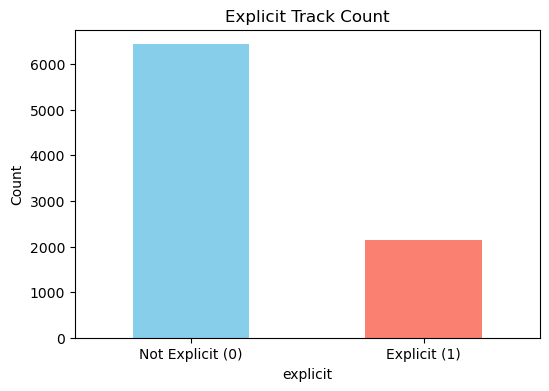

In [15]:
plt.figure(figsize=(6,4))
merged_df['explicit'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Explicit Track Count")
plt.xticks([0,1], ['Not Explicit (0)','Explicit (1)'], rotation=0)
plt.ylabel("Count")
plt.show()

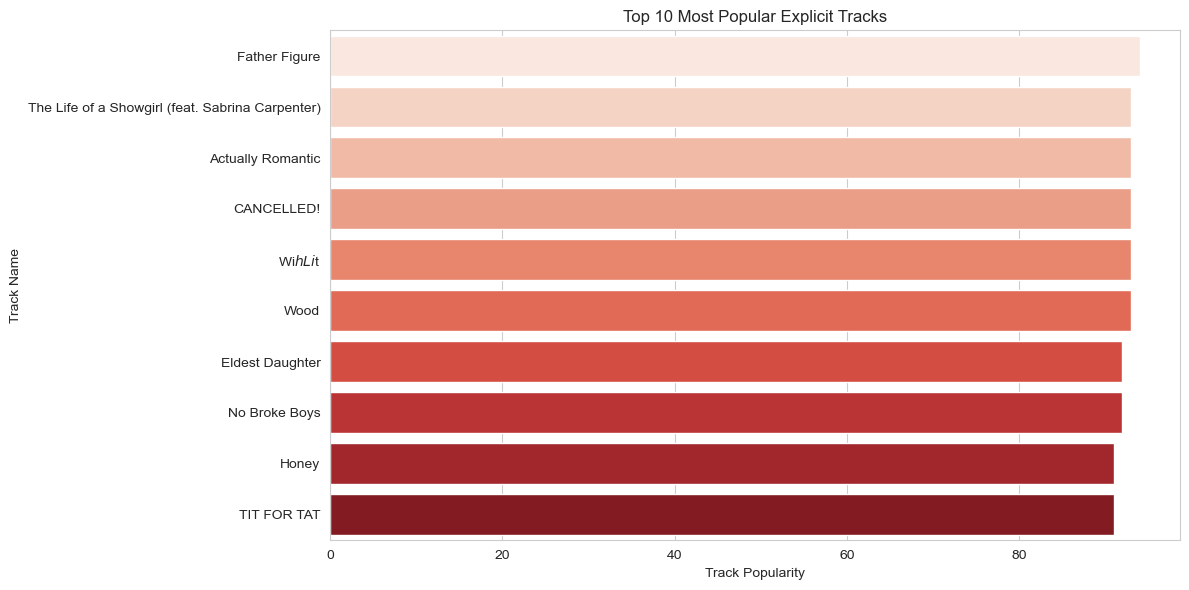

In [33]:
# 1. Filter tracks that are explicit
explicit_tracks = merged_df[merged_df['explicit'] == 1]

# 2. Select top 10 by track popularity (sorted descending)
top10_explicit = explicit_tracks.nlargest(10, 'track_popularity').sort_values('track_popularity', ascending=False)

# 3. Plot horizontal barplot
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

sns.barplot(
    x='track_popularity',
    y='track_name',
    data=top10_explicit,
    palette="Reds"
)

plt.title("Top 10 Most Popular Explicit Tracks")
plt.xlabel("Track Popularity")
plt.ylabel("Track Name")

plt.tight_layout()
plt.show()

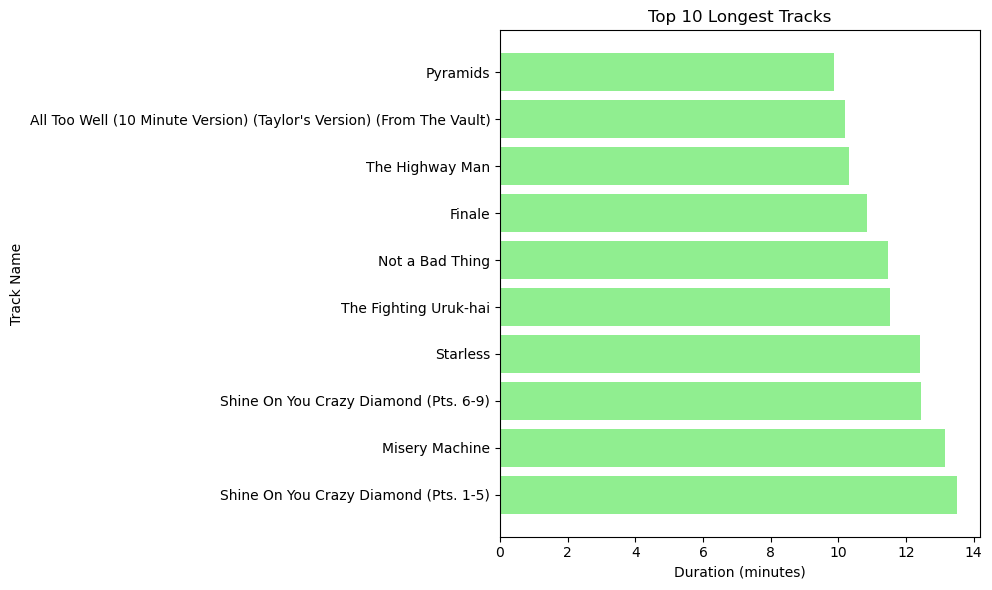

In [29]:
# 1. Select the top 10 longest tracks
top10_longest = merged_df.nlargest(10, 'track_duration_min')

# 2. Plot as horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(top10_longest['track_name'], top10_longest['track_duration_min'], color="lightgreen")
plt.xlabel("Duration (minutes)")
plt.ylabel("Track Name")
plt.title("Top 10 Longest Tracks")
plt.tight_layout()
plt.show()

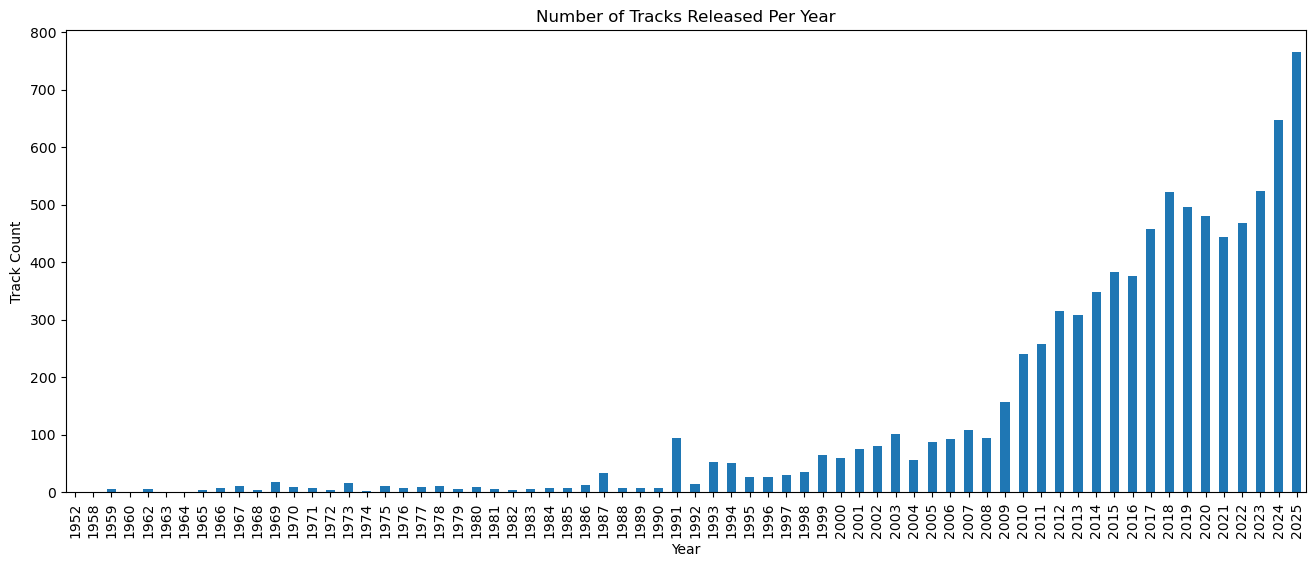

In [17]:
merged_df['year'] = merged_df['album_release_date'].dt.year

plt.figure(figsize=(16,6))
merged_df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Tracks Released Per Year")
plt.xlabel("Year")
plt.ylabel("Track Count")
plt.show()

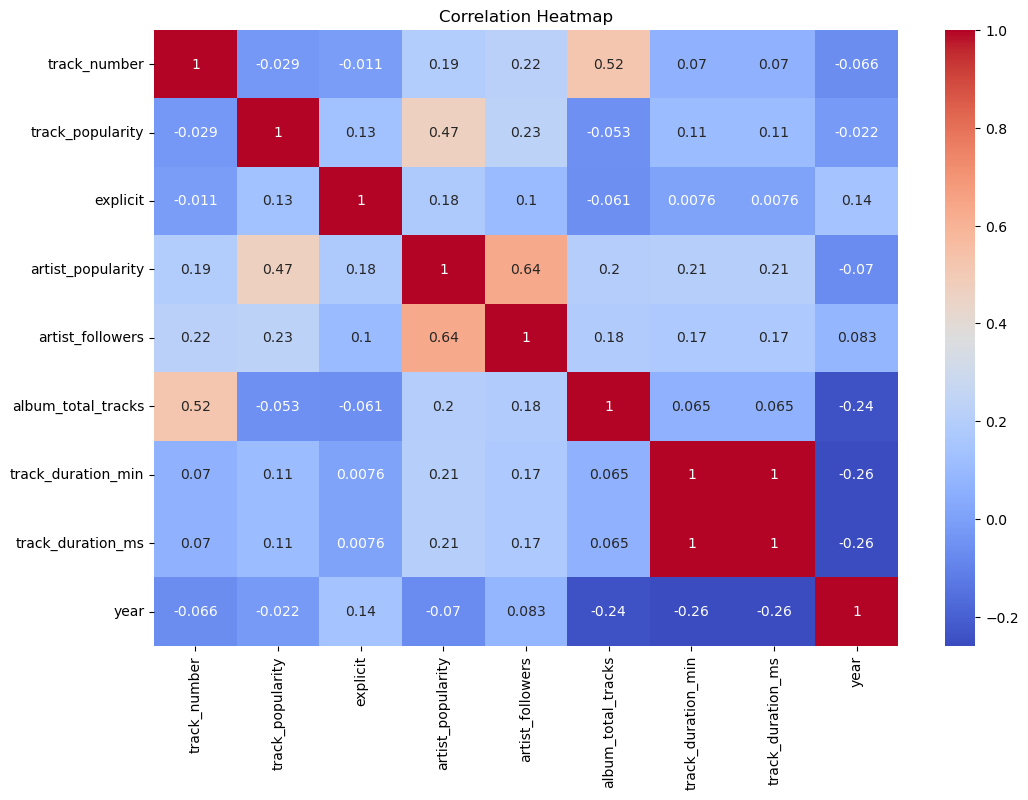

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(merged_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

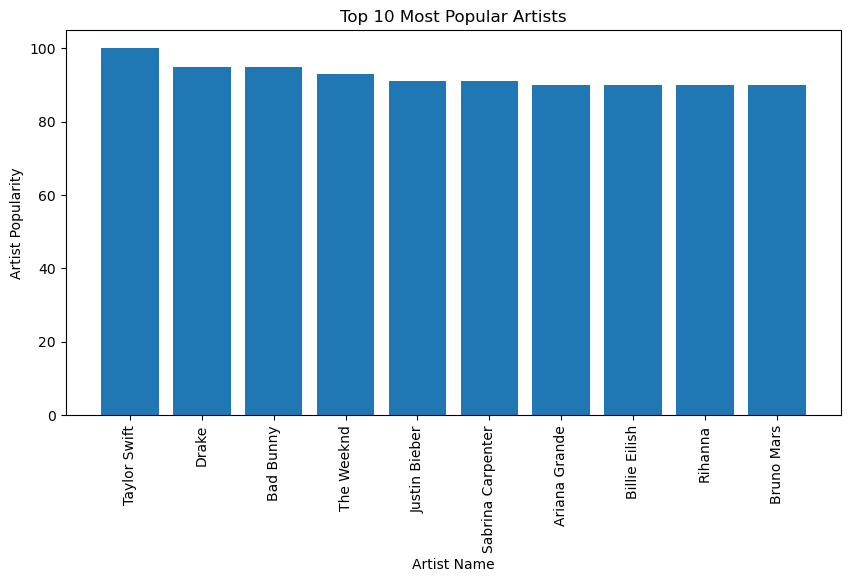

In [23]:
top10_artists = merged_df.drop_duplicates('artist_name').nlargest(10, 'artist_popularity')

plt.figure(figsize=(10,5))
plt.bar(top10_artists['artist_name'], top10_artists['artist_popularity'])
plt.xticks(rotation=90)
plt.title("Top 10 Most Popular Artists")
plt.ylabel("Artist Popularity")
plt.xlabel("Artist Name")
plt.show()

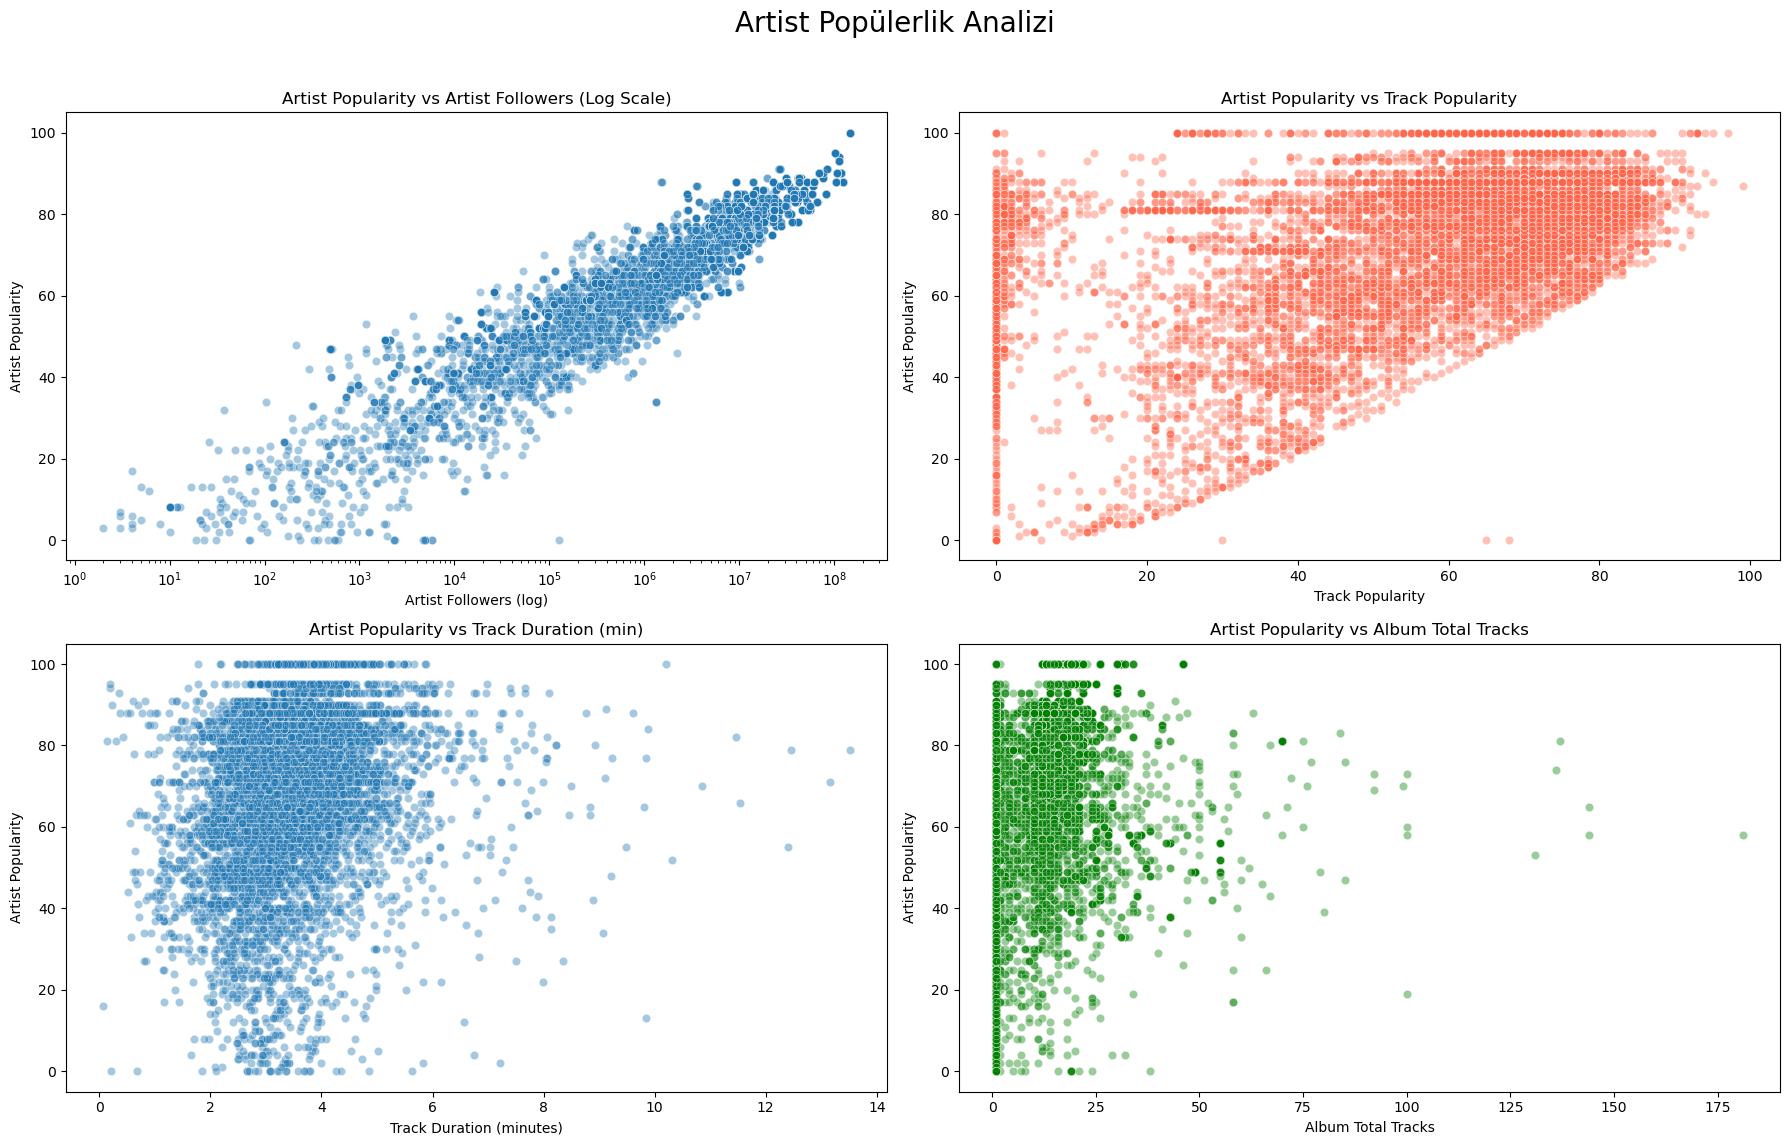

In [24]:
plt.figure(figsize=(18,12))


plt.suptitle("Artist Popularity Analyz", fontsize=20, y=0.95)


# 1) Artist Popularity vs Artist Followers
plt.subplot(2, 2, 1)
sns.scatterplot(data=merged_df, x='artist_followers', y='artist_popularity', alpha=0.4)
plt.xscale('log')
plt.title("Artist Popularity vs Artist Followers (Log Scale)")
plt.xlabel("Artist Followers (log)")
plt.ylabel("Artist Popularity")


# 2) Artist Popularity vs Track Popularity
plt.subplot(2, 2, 2)
sns.scatterplot(data=merged_df, x='track_popularity', y='artist_popularity', alpha=0.4, color="tomato")
plt.title("Artist Popularity vs Track Popularity")
plt.xlabel("Track Popularity")
plt.ylabel("Artist Popularity")


# 3) Artist Popularity vs Track Duration
plt.subplot(2, 2, 3)
sns.scatterplot(data=merged_df, x='track_duration_min', y='artist_popularity', alpha=0.4)
plt.title("Artist Popularity vs Track Duration (min)")
plt.xlabel("Track Duration (minutes)")
plt.ylabel("Artist Popularity")


# 4) Artist Popularity vs Album Total Tracks
plt.subplot(2, 2, 4)
sns.scatterplot(data=merged_df, x='album_total_tracks', y='artist_popularity', alpha=0.4, color="green")
plt.title("Artist Popularity vs Album Total Tracks")
plt.xlabel("Album Total Tracks")
plt.ylabel("Artist Popularity")


plt.tight_layout(rect=[0, 0, 1, 0.93])  
plt.show()